In [2]:
# Init

from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
VALIDATION_SIZE = 0.2
N_REPEATS = 10

DATA_DIR = Path("datasets/titanic")
OUTPUT_DIR = Path("outputs/titanic")

NUMERIC_FEATURES = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "HasCabin",
]
CATEGORICAL_FEATURES = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [3]:
# Load

def load_titanic_data(data_dir):
    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = (
        "https://raw.githubusercontent.com/"
        "ageron/handson-ml2/master/datasets/titanic/"
    )

    for filename in ("train.csv", "test.csv"):
        path = data_dir / filename

        if not path.is_file():
            urlretrieve(base_url + filename, str(path))

    train_df = pd.read_csv(data_dir / "train.csv")
    test_df = pd.read_csv(data_dir / "test.csv")

    return train_df, test_df

train_df, test_df = load_titanic_data(DATA_DIR)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Data splitting

X_full = train_df.drop(columns="Survived")
y_full = train_df["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=VALIDATION_SIZE, stratify=y_full, random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_val.shape)

(712, 11)
(179, 11)


In [5]:
# First Analyze

X_train.info()

summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing": X_train.isnull().sum(),
    "missing_fraction": X_train.isna().mean(),
    "unique_values": X_train.nunique(),
})

summary

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Sex          712 non-null    str    
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    str    
 10  Embarked     710 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 66.8 KB


,dtype,missing,missing_fraction,unique_values
PassengerId,int64,0,0.000000,712
Pclass,int64,0,0.000000,3
Name,str,0,0.000000,712
Sex,str,0,0.000000,2
Age,float64,137,0.192416,85
SibSp,int64,0,0.000000,7
Parch,int64,0,0.000000,7
Ticket,str,0,0.000000,571
Fare,float64,0,0.000000,226
Cabin,str,552,0.775281,127


In [6]:
# More Splitting

target_distribution = pd.DataFrame({
    "count": y_train.value_counts(),
    "fraction": y_train.value_counts(normalize=True),
}).sort_index()

target_distribution

,count,fraction
Survived,,
0,439,0.616573
1,273,0.383427


In [7]:
# Features

def add_features(df):
    res = df.copy()

    title = (
        res["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    )

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    res["Title"] = title.where(title.isin(common_titles), "Rare")
    res["HasCabin"] = (res["Cabin"].notna().astype(int))

    return res

add_features(X_train)[
    ["Name", "Title", "Cabin", "HasCabin"]
].head()

,Name,Title,Cabin,HasCabin
692,"Lam, Mr. Ali",Mr,NaN,0
481,"Frost, Mr. Anthony Wood 'Archie'",Mr,NaN,0
527,"Farthing, Mr. John",Mr,C95,1
855,"Aks, Mrs. Sam (Leah Rosen)",Mrs,NaN,0
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",Mrs,NaN,0


In [9]:
# Pipeline

def build_model(classifier):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    return Pipeline([
        ("features", FunctionTransformer(add_features, validate=False)),
        ("preprocessing", preprocessor),
        ("classifier", clone(classifier)),
    ])

In [10]:
# CV

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

cv_splits = list(cv.split(X_train, y_train))
print(len(cv_splits))

50


In [15]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "svc": SVC(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1,),
    "gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "cat_boost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, thread_count=1,),
    "light_gbm": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
    "xgboost": XGBClassifier(random_state=RANDOM_STATE, verbosity=0, n_jobs=1),
}

cv_scores = {}
rows = []

for name, classifier in classifiers.items():
    candidate = build_model(classifier)

    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv_splits,
        scoring="accuracy",
        n_jobs=-1,
        error_score="raise",
    )

    cv_scores[name] = scores

    rows.append({"model": name, "mean_accuracy": scores.mean(), "std_accuracy": scores.std()})

comparison = (pd.DataFrame(rows).set_index("model").sort_values("mean_accuracy", ascending=False))

print(comparison.round(4))

                     mean_accuracy  std_accuracy
model                                           
cat_boost                   0.8296        0.0301
svc                         0.8274        0.0279
logistic_regression         0.8266        0.0322
gradient_boosting           0.8219        0.0326
light_gbm                   0.8177        0.0372
random_forest               0.8146        0.0314
xgboost                     0.8053        0.0366
dummy                       0.6166        0.0027


In [17]:
from sklearn.model_selection import RandomizedSearchCV, ParameterGrid

params = parameters_grids[selected_name]

# В текущем словаре все значения — списки.
# Не запрашиваем больше комбинаций, чем существует.
n_candidates = min(30, len(ParameterGrid(params)))

search = RandomizedSearchCV(
    estimator=build_model(classifiers[selected_name]),
    param_distributions=params,
    n_iter=n_candidates,
    random_state=RANDOM_STATE,
    scoring="accuracy",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    error_score="raise",
    verbose=1,
)

search.fit(X_train, y_train)

print(selected_name)
print(search.best_params_)
print(search.best_score_)

selected_model = search.best_estimator_

Fitting 50 folds for each of 30 candidates, totalling 1500 fits
cat_boost
{'classifier__learning_rate': 0.03, 'classifier__l2_leaf_reg': 3, 'classifier__iterations': 700, 'classifier__depth': 4}
0.8351127745493944


In [18]:
# Searching for Parameters

selected_name = (comparison.drop(index="dummy").index[0])

parameters_grids = {
    "logistic_regression": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
    },
    "svc": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__gamma": ["scale", 0.01],
        "classifier__kernel": ["rbf"],
    },
    "random_forest": {
        "classifier__max_depth": [6, None],
        "classifier__min_samples_leaf": [1, 3],
    },
    "gradient_boosting": {
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_iter": [100, 200],
        "classifier__max_leaf_nodes": [7, 15, 31],
        "classifier__min_samples_leaf": [10, 20, 30],
        "classifier__l2_regularization": [0.0, 1.0],
    },
    "cat_boost": {
        "classifier__iterations": [300, 700],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__depth": [4, 6, 8],
        "classifier__l2_leaf_reg": [1, 3, 10],
    },
    "light_gbm": {
        "classifier__n_estimators": [100, 300],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__num_leaves": [7, 15, 31],
        "classifier__max_depth": [3, 5, -1],
        "classifier__min_child_samples": [10, 20, 30],
    },
    "xgboost": {
        "classifier__n_estimators": [100, 300],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [2, 4, 6],
        "classifier__min_child_weight": [1, 3, 5],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
    },
}

search = GridSearchCV(
    estimator=build_model(classifiers[selected_name]),
    param_grid=parameters_grids[selected_name],
    scoring="accuracy",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

search.fit(X_train, y_train)

print(selected_name)
print(search.best_params_)
print(search.best_score_)

selected_model = search.best_estimator_

cat_boost
{'classifier__depth': 4, 'classifier__iterations': 700, 'classifier__l2_leaf_reg': 3, 'classifier__learning_rate': 0.03}
0.8351127745493944


In [20]:
from sklearn.model_selection import RandomizedSearchCV, ParameterGrid

tuned_models = {}
tuning_rows = []

for name, params in parameters_grids.items():
    print(f"\nSearching: {name}")

    search = RandomizedSearchCV(
        estimator=build_model(classifiers[name]),
        param_distributions=params,
        n_iter=min(30, len(ParameterGrid(params))),
        random_state=RANDOM_STATE,
        scoring="accuracy",
        cv=cv_splits,
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )

    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "best_cv_accuracy": search.best_score_,
        "best_params": search.best_params_,
    })

tuning_comparison = (
    pd.DataFrame(tuning_rows)
    .set_index("model")
    .sort_values("best_cv_accuracy", ascending=False)
)

print(tuning_comparison)


Searching: logistic_regression

Searching: svc

Searching: random_forest

Searching: gradient_boosting

Searching: cat_boost

Searching: light_gbm

Searching: xgboost
                     best_cv_accuracy  \
model                                   
cat_boost                    0.835113   
light_gbm                    0.834407   
gradient_boosting            0.833844   
xgboost                      0.831469   
svc                          0.830480   
random_forest                0.828790   
logistic_regression          0.826551   

                                                           best_params  
model                                                                   
cat_boost            {'classifier__learning_rate': 0.03, 'classifie...  
light_gbm            {'classifier__num_leaves': 15, 'classifier__n_...  
gradient_boosting    {'classifier__min_samples_leaf': 20, 'classifi...  
xgboost              {'classifier__subsample': 1.0, 'classifier__n_...  
svc                  {'c

Validation accuracy: 0.8156
              precision    recall  f1-score   support

           0      0.835     0.873     0.853       110
           1      0.781     0.725     0.752        69

    accuracy                          0.816       179
   macro avg      0.808     0.799     0.803       179
weighted avg      0.814     0.816     0.814       179



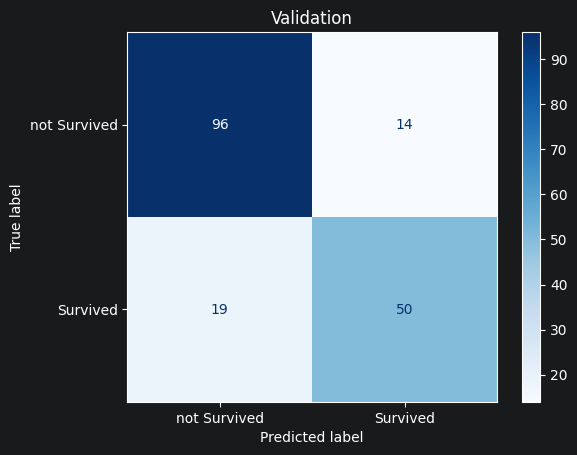

In [19]:
# Grading Model

val_predictions = selected_model.predict(X_val)

validation_accuracy = accuracy_score(y_val, val_predictions)

print(f"Validation accuracy: {validation_accuracy:.4f}")

print(classification_report(y_val, val_predictions, digits=3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_val, val_predictions, display_labels=["not Survived", "Survived"], cmap="Blues")
plt.title("Validation")
plt.show()

In [35]:
# Analyzing Model Errors

validation_details = add_features(X_val)

validation_details["actual"] = y_val
validation_details["predictions"] = val_predictions

errors = validation_details.loc[
    validation_details["actual"] != validation_details["predictions"]
].copy()

print("errors: ", len(errors))

errors[[
    "PassengerId",
    "Sex",
    "Age",
    "Pclass",
    "Title",
    "HasCabin",
    "actual",
    "predictions",
]].head(15)

errors:  33


,PassengerId,Sex,Age,Pclass,Title,HasCabin,actual,predictions
553,554,male,22.0,3,Mr,0,1,0
559,560,female,36.0,3,Mrs,0,1,0
536,537,male,45.0,1,Rare,1,0,1
698,699,male,49.0,1,Mr,1,0,1
216,217,female,27.0,3,Miss,0,1,0
279,280,female,35.0,3,Mrs,0,1,0
712,713,male,48.0,1,Mr,1,1,0
455,456,male,29.0,3,Mr,0,1,0
489,490,male,9.0,3,Master,0,1,0
165,166,male,9.0,3,Master,0,1,0


In [26]:
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier

estimators = []

for name, model in tuned_models.items():
    candidate = clone(model)

    if name == "svc":
        candidate.set_params(classifier__probability=True)

    estimators.append((name, candidate))

ensemble = VotingClassifier(
    estimators=estimators,
    voting="hard",
    weights=None,  # одинаковый вес каждой модели
    n_jobs=1,
)

ensemble.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logistic_regression', ...), ('svc', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7caea11c5f80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


In [27]:
best_single_name = tuning_comparison.index[0]

single_predictions = tuned_models[best_single_name].predict(X_val)
ensemble_predictions = ensemble.predict(X_val)

print(
    f"{best_single_name}:",
    f"{accuracy_score(y_val, single_predictions):.4f}",
)
print(
    "Soft voting:",
    f"{accuracy_score(y_val, ensemble_predictions):.4f}",
)

cat_boost: 0.8156
Soft voting: 0.8156


In [28]:
selected_model = ensemble

final_model = clone(selected_model)
final_model.fit(X_full, y_full)

predictions = final_model.predict(test_df)

In [1]:
# Final Model

final_model = clone(selected_model)

final_model.fit(X_full, y_full)

NameError: name 'clone' is not defined

In [24]:
# Predictions on test.csv

test_predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions.astype(int),
})

assert len(submission) == len(test_df)
assert submission["PassengerId"].equals(test_df["PassengerId"])
assert submission["Survived"].isin([0, 1]).all()
assert not submission.isna().any().any()

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [38]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

submission_path = OUTPUT_DIR / "submission.csv"

submission.to_csv(OUTPUT_DIR / "model_comparison.csv")

pd.DataFrame(cv_scores).to_csv(OUTPUT_DIR / "cv_scores.csv", index=False)

print("Done")

Done


In [29]:
# Submission for Kaggle

from pathlib import Path
from sklearn.base import clone
import pandas as pd

final_model = clone(selected_model)
final_model.fit(X_full, y_full)

predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions.astype(int),
})

assert submission.shape == (418, 2)
assert not submission.isna().any().any()
assert submission["Survived"].isin([0, 1]).all()

submission_path = Path("outputs/titanic/submission.csv")
submission_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(submission_path, index=False)

print("File:", submission_path.resolve())

File: /home/kolja/home/kole4ka_bot/first-ml-project/training/titanic/outputs/titanic/submission.csv
